In [6]:
# Import the necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import time

In [7]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

In [8]:
# Parameters
betta = 0.95
alpha = 0.3
delta = 0.1
sigma = 2.0

maxiter = 10000

In [9]:
k_min = 0.1
k_max = 5.0
nk = 200

kgrid = np.linspace(k_min,k_max,nk)

In [10]:
v_guess = np.zeros(nk)
v_new = np.zeros(nk)
kprime = np.zeros(nk)
kp_ind = np.zeros(nk,dtype=int)


# The main loop
time_start = time.time()

for iter1 in range(maxiter):

    for ik in range(nk):

        val = np.zeros(nk)

        for ikk in range(nk):

            # Calculate for each k' the RHS of the Bellman equation
            con = kgrid[ik]**alpha+(1-delta)*kgrid[ik]-kgrid[ikk]
            if (con<=0.0):
                val[ikk] = -1000000.0
            else:
                val[ikk] = (con**(1.0-sigma)-1.0)/(1.0-sigma) + betta*v_guess[ikk]

        # and choose the k' that maximizes this expression;
        # store the index (using np.argmax), the corresponding grid value, and the function value
        v_new[ik] = np.amax(val)
        kp_ind[ik] = np.argmax(val)
        kprime[ik] = kgrid[kp_ind[ik]]

    # Calculate the distance between your old guess and the obtained function values
    metric = np.amax(np.abs(v_new-v_guess))

    # You may want to print your metric to see if the algorithm converges
    #print(iter1,metric)

    # Check for convergence
    if metric<1e-5:
        break

    # Set the new guess for V
    v_guess[:] = v_new

time_end = time.time()
print('Computational time: ', time_end-time_start, 'seconds')

Computational time:  6.493263006210327 seconds


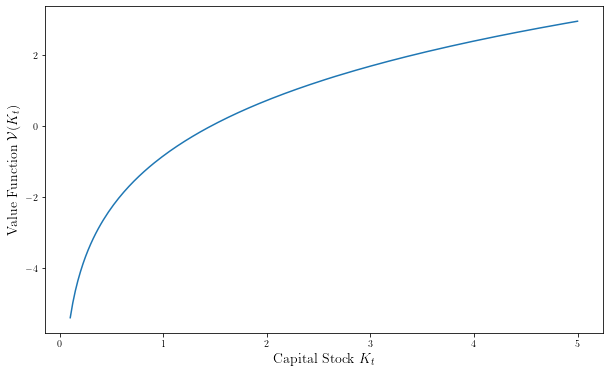

In [11]:
# Plot the resulting value function
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(kgrid, v_new)
ax.set_xlabel('Capital Stock $K_t$', fontsize=14)
ax.set_ylabel('Value Function $\mathcal{V}(K_t)$', fontsize=14)
plt.show()

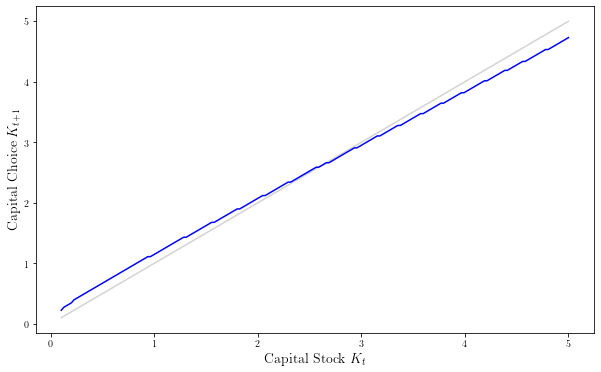

In [12]:
# Plot the resulting policy function
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(kgrid,kgrid,color='lightgray')
ax.plot(kgrid,kprime,color='blue')
ax.set_xlabel('Capital Stock $K_t$', fontsize=14)
ax.set_ylabel('Capital Choice $K_{t+1}$', fontsize=14)
plt.show()

Average Euler Error:  0.009343679502566954
Maximum Euler Error:  0.045459822939446504


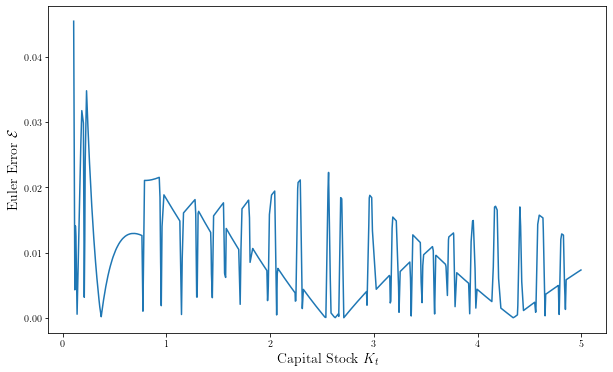

In [13]:
# Compute Euler equation errors
np.random.seed(23112021)
neval = 1000
eval_pts = np.sort(k_min+np.random.rand(neval)*(k_max-k_min))
kp_int = np.interp(eval_pts,kgrid,kprime)
kpp_int = np.interp(kp_int,kgrid,kprime)
c_pol = eval_pts**alpha + (1.0-delta)*eval_pts - kp_int
cp_pol = kp_int**alpha + (1.0-delta)*kp_int - kpp_int

EErrors = np.zeros(neval)

for ie in range(neval):
    EErrors[ie] = np.abs((c_pol[ie]/(betta*((alpha*kp_int[ie]**(alpha-1.0)+1.0-delta)*cp_pol[ie]**(-sigma)))**(-1.0/sigma))-1.0)

# Maximum Euler error
max_error = np.amax(EErrors)
# Average Euler error
avg_error = np.mean(EErrors)

print('Average Euler Error: ', avg_error)
print('Maximum Euler Error: ', max_error)

fig, ax = plt.subplots(figsize=(10,6))
ax.plot(eval_pts,EErrors)
ax.set_xlabel('Capital Stock $K_t$', fontsize=14)
ax.set_ylabel('Euler Error $\mathcal{E}$', fontsize=14)
plt.show()